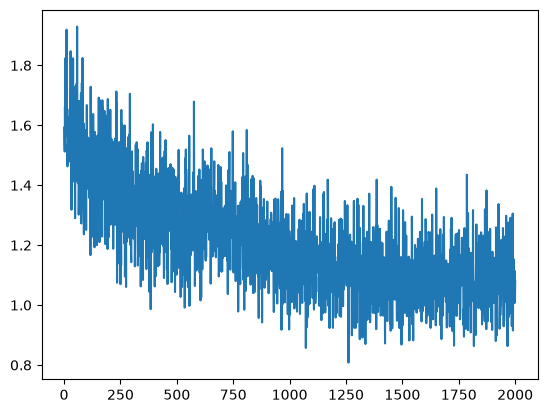

In [1]:
# import libraries
import matplotlib.pyplot as plt
from sckitflow import ModelBuilder
from sckitflow.core.methods import OptimConfig
from sckitflow.dataset.toy_data import get_toy_dataset

# create dataset
adata = get_toy_dataset("moons", noise=0.1).adata

# step 1: prepare the data (schema)
builder = ModelBuilder.from_adata(adata)

# step 2: attach the method and get a ready-to-train model
# Keep documentation and CI execution independent of GPU availability.
model = builder.build(
    method_id="cfm",
    device_id="cpu",
    vf_decoder_mlp_kwargs={
        "hidden_dims": [
            32,
            32,
        ]
    },
    time_features_id="torch-cfm",
    conditioning_id="resnet1d",
    # probability_path=probability_paths.SchrodingerBridgeProbabilityPath(1.0)
)

# train model
# No covariates and no split column declared on the schema: the whole dataset streams as one loader
# as one implicit group, which is what unconditional generation wants.
model.train(adata, n_train_steps=2_000, optim_config=OptimConfig(lr=1e-4))

plt.plot(model.trainer.get_train_logs_df()["loss"])

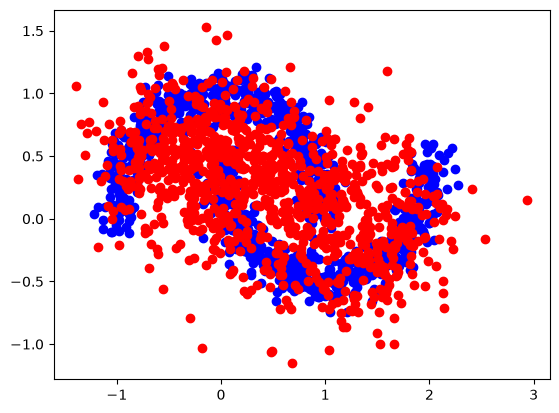

In [2]:
# predict
# CFM here generates from noise (there is no source distribution), so `predict`
# needs to be told how many samples to draw per observation.
adata_pred = model.predict(adata, predict_kwargs={"n_samples": 1})

# visualize
plt.scatter(
    adata.X[:, 0],
    adata.X[:, 1],
    color="blue",
)
plt.scatter(adata_pred.X[:, 0], adata_pred.X[:, 1], color="red")